In [1]:
from utils import *
from DRAG import * 
sigma = 1.0
tg = 250.0
s = Simulation()

In [2]:
import os
import pickle
import sympy as sy

# --- Parameter für den Dateiabruf ---
load_sigma = sigma
load_tg = tg

tg_int = int(round(load_tg))
filename = f"pulse_shape_sigma_{load_sigma:.1f}_tg_{tg_int}ns.pkl"
filepath = os.path.join("operational_res/final_forms", filename)

if not os.path.exists(filepath):
    raise FileNotFoundError(f"❌ Datei nicht gefunden: {filepath}")

# 1. Datei laden
with open(filepath, "rb") as f:
    loaded_data = pickle.load(f)

# 2. SymPy Ausdrücke & Simulationsdaten extrahieren
A_t_sym = loaded_data["sympy_expressions"]["A_t"]
wd_t_sym = loaded_data["sympy_expressions"]["wd_t"]
t_sym = loaded_data["sympy_expressions"]["t_symbol"]

tlist = loaded_data["simulation_data"]["tlist"]
best_psi_t_ref = loaded_data["simulation_data"]["best_psi_t"]

# 3. Ausgaben zur Kontrolle
print(f"✅ Erfolgreich geladen: {filepath}")
print(f"   Gespeicherte Infidelity: {loaded_data['metadata']['best_infidelity']:.6e}")
print(f"   Frequenz-Modell         : {loaded_data['metadata']['freq_model']}")

print("\n--- Optimierte Sweep-Parameter ---")
for k, v in loaded_data["best_parameters"].items():
    print(f"  {k:15s}: {v:.10g}")

✅ Erfolgreich geladen: operational_res/final_forms/pulse_shape_sigma_1.0_tg_250ns.pkl
   Gespeicherte Infidelity: 9.693159e-07
   Frequenz-Modell         : gauss_erf

--- Optimierte Sweep-Parameter ---
  freq_offset    : 0.0003648255338
  scale_A        : 1.025729791


<>:32: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:32: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/var/folders/7k/3h2gl4fs7gb1hdzh7fl2mc940000gn/T/ipykernel_2900/2744453281.py:32: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  plt.ylabel('Population $|\psi(t)|^2$')


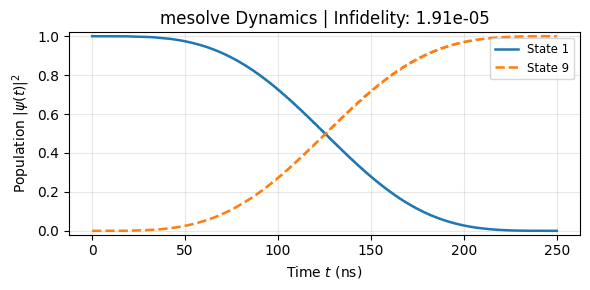

In [3]:
import numpy as np
import sympy as sy
import matplotlib.pyplot as plt

# 1. Puls auf feinem Zeitraster auswerten
N_t_mesolve = 1001
tlist_mesolve = np.linspace(0, load_tg, N_t_mesolve)

A_np = sy.lambdify(t_sym, A_t_sym, modules=['numpy', 'scipy'])(tlist_mesolve)
wd_np = sy.lambdify(t_sym, wd_t_sym, modules=['numpy', 'scipy'])(tlist_mesolve)

def qutip_signal(t, args=None):
    idx = min(int(t / load_tg * (N_t_mesolve - 1)), N_t_mesolve - 1)
    return float(np.real(A_np[idx]) * np.cos(wd_np[idx] * t) + np.imag(A_np[idx]) * np.sin(wd_np[idx] * t))

# 2. Mesolve-Dynamik berechnen
H = [s.H0, [s.V1, qutip_signal]]
res_keys = list(dict(s.resonances).keys()) if isinstance(s.resonances, list) else list(s.resonances.keys())
ind_a, ind_b = res_keys.index(s.state_a), res_keys.index(s.state_b)

amp_a = resonant_subspace_column_evolution(H, tlist_mesolve, ind_a, debug=False, s=s)
amp_b = resonant_subspace_column_evolution(H, tlist_mesolve, ind_b, debug=False, s=s)

infid_mesolve = 1.0 - 0.5 * (np.abs(amp_a[ind_b, -1])**2 + np.abs(amp_b[ind_a, -1])**2)

# 3. Plot
plt.figure(figsize=(6, 3))
plt.plot(tlist_mesolve, np.abs(amp_a[ind_a, :])**2, label=f'State {s.state_a}', lw=1.8)
plt.plot(tlist_mesolve, np.abs(amp_a[ind_b, :])**2, label=f'State {s.state_b}', lw=1.8, ls='--')

plt.xlabel('Time $t$ (ns)')
plt.ylabel('Population $|\psi(t)|^2$')
plt.title(f'mesolve Dynamics | Infidelity: {infid_mesolve:.2e}')
plt.ylim(-0.02, 1.02)
plt.grid(True, alpha=0.3)
plt.legend(frameon=True, fontsize='small')
plt.tight_layout()
plt.show()

Now let's compute the effective Hamiltonian as a function of time for this analytic pulse shape, then afterwards plot key elements of this effective Hamiltonian as a function of time. Important magntitudes are $\delta_{aa}$ and $\frac{\Omega_ab}{\Omega_bc}$

In [4]:
import numpy as np
import sympy as sy
from FAPT import *

# 1. Symbolische Ableitungen der Pulsformen nach Zeit t_sym berechnen
dA_t_sym = sy.diff(A_t_sym, t_sym)
dwd_t_sym = sy.diff(wd_t_sym, t_sym)

print("Berechne symbolisches H_eff(t)...")

# Monkey-Patch: np.exp kurzzeitig auf sy.exp umleiten für symbolische FAPT-Evaluation
np_exp_backup = np.exp
np.exp = sy.exp

try:
    Heff_sym = Heff_Floquet_total_matrix_summed(
        rH=getattr(s, 'rH', 2),
        wd=wd_t_sym,
        A=A_t_sym,
        resonances=s.resonances,
        E=s.E_array,
        V_posHarm=s.V1_dressed_array,
        V0=getattr(s, 'V0', None),
        ref_state=getattr(s, 'ref_state', None),
        dwd=dwd_t_sym,
        dA=dA_t_sym,
        t=t_sym,
        analytics=True,
        include_geometric=True,
        include_micromotion=True,
        include_g_correction=True,
        verbose=False,
        rW=getattr(s, 'rW', 1)
    )
finally:
    # NumPy-Verhalten sicherstellen
    np.exp = np_exp_backup

print("✅ Symbolisches H_eff(t) fertig berechnet.")

Berechne symbolisches H_eff(t)...
✅ Symbolisches H_eff(t) fertig berechnet.


--- DIAGNOSE RATIO ---
Max. Imaginärteil von Ratio: 4.997788250449603e-07
Max. Realteil von Ratio: 0.09979551143688273
Max. Betrag von Ratio: 0.09979551143689609
-----------------------


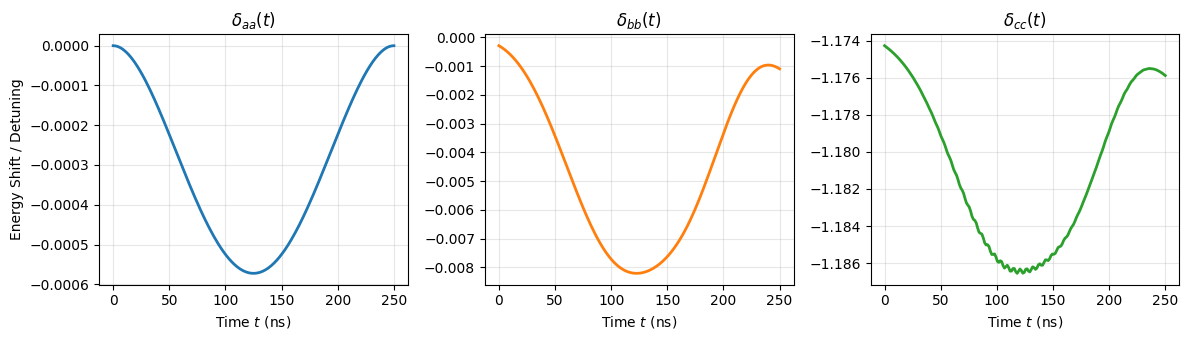

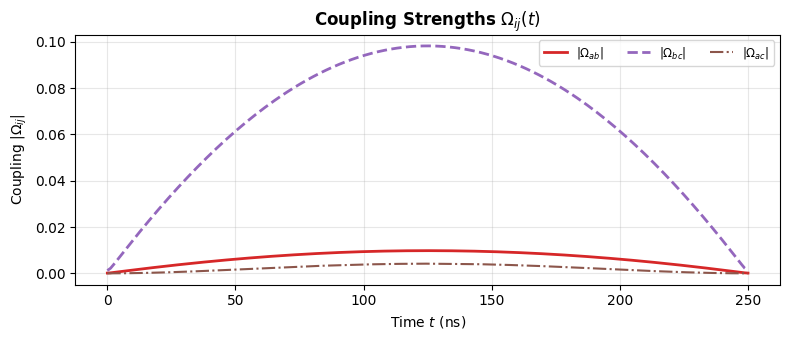

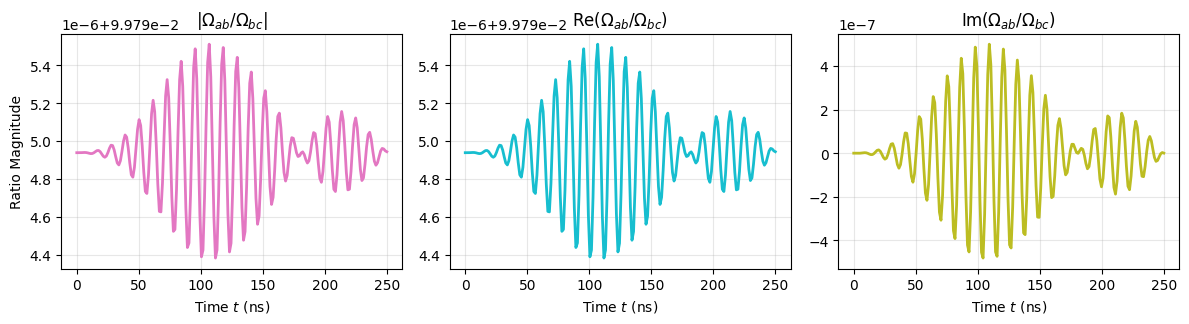

In [5]:
import numpy as np
import sympy as sy
import matplotlib.pyplot as plt

# 1. Indizes für die Zustände bestimmen
res_keys = list(dict(s.resonances).keys()) if isinstance(s.resonances, list) else list(s.resonances.keys())

ind_a = res_keys.index(s.state_a)
ind_b = res_keys.index(s.state_b)
ind_c = res_keys.index(s.state_c) if hasattr(s, 'state_c') else (ind_b + 1) % len(res_keys)

# 2. Symbolische Matrixelemente extrahieren
delta_aa_sym = sy.re(Heff_sym[ind_a, ind_a])
delta_bb_sym = sy.re(Heff_sym[ind_b, ind_b])
delta_cc_sym = sy.re(Heff_sym[ind_c, ind_c])

Omega_ab_sym = Heff_sym[ind_a, ind_b]
Omega_bc_sym = Heff_sym[ind_b, ind_c]
Omega_ac_sym = Heff_sym[ind_a, ind_c]

# 3. Ausdrücke lambdifizieren (Explizit komplexe Auswertung erzwingen)
delta_aa_func = sy.lambdify(t_sym, delta_aa_sym, modules=['numpy', 'scipy'])
delta_bb_func = sy.lambdify(t_sym, delta_bb_sym, modules=['numpy', 'scipy'])
delta_cc_func = sy.lambdify(t_sym, delta_cc_sym, modules=['numpy', 'scipy'])

Omega_ab_func = sy.lambdify(t_sym, Omega_ab_sym, modules=['numpy', 'scipy'])
Omega_bc_func = sy.lambdify(t_sym, Omega_bc_sym, modules=['numpy', 'scipy'])
Omega_ac_func = sy.lambdify(t_sym, Omega_ac_sym, modules=['numpy', 'scipy'])

# 4. Zeitraster evaluieren
N_t = 200
tlist_mesolve = np.linspace(0, load_tg, N_t)

delta_aa_vals = np.asarray(delta_aa_func(tlist_mesolve), dtype=np.float64)
delta_bb_vals = np.asarray(delta_bb_func(tlist_mesolve), dtype=np.float64)
delta_cc_vals = np.asarray(delta_cc_func(tlist_mesolve), dtype=np.float64)

# Explizit als komplexe Werte einlesen!
Omega_ab_vals = np.asarray(Omega_ab_func(tlist_mesolve), dtype=np.complex128)
Omega_bc_vals = np.asarray(Omega_bc_func(tlist_mesolve), dtype=np.complex128)
Omega_ac_vals = np.asarray(Omega_ac_func(tlist_mesolve), dtype=np.complex128)

# Komplexe Ratio (Epsilon schützt vor Div/0)
ratio_Omega_complex = Omega_ab_vals / (Omega_bc_vals + 1e-15)

# === DIAGNOSE PRINT IN DER KONSOLE ===
print("--- DIAGNOSE RATIO ---")
print("Max. Imaginärteil von Ratio:", np.max(np.abs(np.imag(ratio_Omega_complex))))
print("Max. Realteil von Ratio:", np.max(np.abs(np.real(ratio_Omega_complex))))
print("Max. Betrag von Ratio:", np.max(np.abs(ratio_Omega_complex)))
print("-----------------------")

# ==========================================
# PLOT 1: Die 3 Deltas nebeneinander
# ==========================================
fig1, (ax_a, ax_b, ax_c) = plt.subplots(1, 3, figsize=(12, 3.5), dpi=100)

ax_a.plot(tlist_mesolve, delta_aa_vals, color='#1f77b4', lw=2)
ax_a.set_title(r'$\delta_{aa}(t)$', fontweight='bold')
ax_a.set_xlabel(r'Time $t$ (ns)')
ax_a.set_ylabel(r'Energy Shift / Detuning')
ax_a.grid(True, alpha=0.3)

ax_b.plot(tlist_mesolve, delta_bb_vals, color='#ff7f0e', lw=2)
ax_b.set_title(r'$\delta_{bb}(t)$', fontweight='bold')
ax_b.set_xlabel(r'Time $t$ (ns)')
ax_b.grid(True, alpha=0.3)

ax_c.plot(tlist_mesolve, delta_cc_vals, color='#2ca02c', lw=2)
ax_c.set_title(r'$\delta_{cc}(t)$', fontweight='bold')
ax_c.set_xlabel(r'Time $t$ (ns)')
ax_c.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# PLOT 2: Kopplungsstärken
# ==========================================
fig2, ax_coupl = plt.subplots(figsize=(8, 3.5), dpi=100)

ax_coupl.plot(tlist_mesolve, np.abs(Omega_ab_vals), label=r'$|\Omega_{ab}|$', color='#d62728', lw=2)
ax_coupl.plot(tlist_mesolve, np.abs(Omega_bc_vals), label=r'$|\Omega_{bc}|$', color='#9467bd', lw=2, ls='--')
ax_coupl.plot(tlist_mesolve, np.abs(Omega_ac_vals), label=r'$|\Omega_{ac}|$', color='#8c564b', lw=1.5, ls='-.')
ax_coupl.set_xlabel(r'Time $t$ (ns)')
ax_coupl.set_ylabel(r'Coupling $|\Omega_{ij}|$')
ax_coupl.set_title(r'Coupling Strengths $\Omega_{ij}(t)$', fontweight='bold')
ax_coupl.grid(True, alpha=0.3)
ax_coupl.legend(loc='upper right', frameon=True, fontsize='small', ncol=3)

plt.tight_layout()
plt.show()

# ==========================================
# PLOT 3: Ratios nebeneinander
# ==========================================
fig3, (ax_abs, ax_re, ax_im) = plt.subplots(1, 3, figsize=(12, 3.5), dpi=100)

# 1. Betrag der Ratio
ax_abs.plot(tlist_mesolve, np.abs(ratio_Omega_complex), color='#e377c2', lw=2)
ax_abs.set_title(r'$|\Omega_{ab} / \Omega_{bc}|$', fontweight='bold')
ax_abs.set_xlabel(r'Time $t$ (ns)')
ax_abs.set_ylabel(r'Ratio Magnitude')
ax_abs.grid(True, alpha=0.3)

# 2. Realteil der Ratio
ax_re.plot(tlist_mesolve, np.real(ratio_Omega_complex), color='#17becf', lw=2)
ax_re.set_title(r'$\mathrm{Re}(\Omega_{ab} / \Omega_{bc})$', fontweight='bold')
ax_re.set_xlabel(r'Time $t$ (ns)')
ax_re.grid(True, alpha=0.3)

# 3. Imaginärteil der Ratio (mit optischem Check gegen Rauschen)
im_vals = np.imag(ratio_Omega_complex)
ax_im.plot(tlist_mesolve, im_vals, color='#bcbd22', lw=2)
ax_im.set_title(r'$\mathrm{Im}(\Omega_{ab} / \Omega_{bc})$', fontweight='bold')
ax_im.set_xlabel(r'Time $t$ (ns)')
ax_im.grid(True, alpha=0.3)

# Falls der Imaginärteil praktisch 0 ist (z.B. < 1e-12), Y-Limits fixieren, damit Matplotlib nicht rauscht:
if np.max(np.abs(im_vals)) < 1e-10:
    ax_im.set_ylim(-1, 1)

plt.tight_layout()
plt.show()

Vergleich mit H_t

In [ ]:
import numpy as np
import sympy as sy
import matplotlib.pyplot as plt
from FAPT import *

USE_TIME_DEPENDENT_PARAMS = True

# 1. Symbolisches H_eff berechnen & in SymPy-Matrix wandeln
dA_t_sym, dwd_t_sym = sy.diff(A_t_sym, t_sym), sy.diff(wd_t_sym, t_sym)
np_backup, np.exp = np.exp, sy.exp
try:
    Heff_raw = Heff_Floquet_total_matrix_summed(
        rH=getattr(s, 'rH', 2), wd=wd_t_sym, A=A_t_sym, resonances=s.resonances,
        E=s.E_array, V_posHarm=s.V1_dressed_array, V0=getattr(s, 'V0', None),
        ref_state=getattr(s, 'ref_state', None), dwd=dwd_t_sym, dA=dA_t_sym,
        t=t_sym, analytics=True, include_geometric=True, include_micromotion=True,
        include_g_correction=True, verbose=False, rW=getattr(s, 'rW', 1)
    )
finally:
    np.exp = np_backup

Heff_sym = sy.Matrix(Heff_raw)

# 2. Indizes, Eichung (delta_aa = 0) & Substitutionen (sol_params, sol_dwd)
res_keys = list(dict(s.resonances).keys()) if isinstance(s.resonances, list) else list(s.resonances.keys())
ind_a, ind_b = res_keys.index(s.state_a), res_keys.index(s.state_b)
ind_c = res_keys.index(s.state_c) if hasattr(s, 'state_c') else (ind_b + 1) % len(res_keys)

Heff_sym -= sy.re(Heff_sym[ind_a, ind_a]) * sy.eye(Heff_sym.rows)

subs_dict = {**globals().get('sol_params', {}), **globals().get('sol_dwd', {})}
Heff_sym = Heff_sym.subs(subs_dict)
if 'clean_expr' in globals():
    Heff_sym = sy.Matrix([[clean_expr(e) for e in Heff_sym.row(r)] for r in range(Heff_sym.rows)])

# 3. Parameter-Ausdrücke & Auswertung
delta_aa_sym, delta_bb_sym = sy.re(Heff_sym[ind_a, ind_a]), sy.re(Heff_sym[ind_b, ind_b])
Omega_ab_sym, Omega_bc_sym = Heff_sym[ind_a, ind_b], Heff_sym[ind_b, ind_c]

Delta_sym_t = delta_bb_sym - 2 * delta_aa_sym
rrr_sym_t = Omega_bc_sym / (Omega_ab_sym + 1e-15)

tlist = np.linspace(0, load_tg, 500)
Delta_vals = sy.lambdify(t_sym, Delta_sym_t, ['numpy', 'scipy'])(tlist)
rrr_vals = sy.lambdify(t_sym, rrr_sym_t, ['numpy', 'scipy'])(tlist)

if not USE_TIME_DEPENDENT_PARAMS:
    Delta_param, rrr_param = float(np.mean(Delta_vals)), complex(np.mean(rrr_vals))
    print(f"[Option 1] Konstant: Delta = {Delta_param:.6f}, rrr = {rrr_param:.6f}")
else:
    Delta_param, rrr_param = Delta_sym_t, rrr_sym_t
    print("[Option 2] Zeitabhängige Ausdrücke Delta(t) und rrr(t) aktiv.")

[Option 2 AKTIV] Zeitabhängige symbolische Ausdrücke Delta(t) und rrr(t) verwendet.


ValueError: x and y must have same first dimension, but have shapes (200,) and (500,)

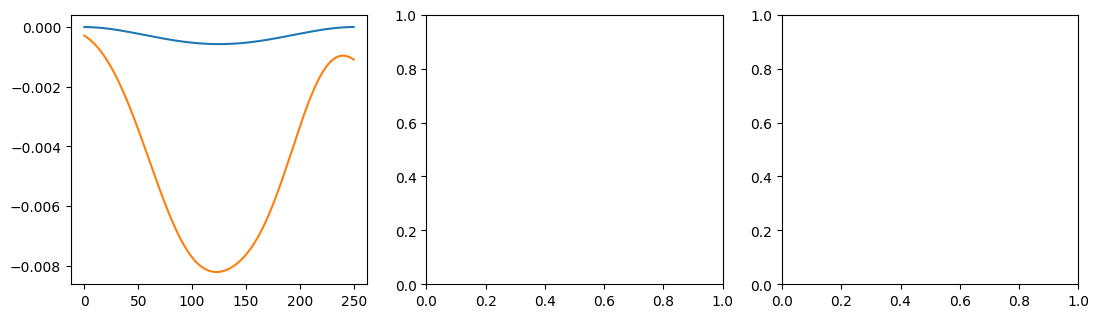

In [11]:
# ==========================================
# PLOT-CODE
# ==========================================
# Einzelne Kopplungen & Shifts lambdifizieren (verhindert Symbolik-Hänger)
delta_aa_vals = sy.lambdify(t_sym, delta_aa_sym, ['numpy', 'scipy'])(tlist)
delta_bb_vals = sy.lambdify(t_sym, delta_bb_sym, ['numpy', 'scipy'])(tlist)
Omega_ab_vals = sy.lambdify(t_sym, Omega_ab_sym, ['numpy', 'scipy'])(tlist)
Omega_bc_vals = sy.lambdify(t_sym, Omega_bc_sym, ['numpy', 'scipy'])(tlist)

# Numerische Auswertung von rrr(t) (vermeidet 0-Division)
rrr_vals_plot = Omega_bc_vals / (Omega_ab_vals + 1e-15)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), dpi=100)

# 1. Plot: Detunings / Energy Shifts
axes[0].plot(tlist, delta_aa_vals, label=r'$\delta_{aa} \equiv 0$')
axes[0].plot(tlist, delta_bb_vals, label=r'$\delta_{bb}$')
axes[0].plot(tlist, Delta_vals, label=r'$\Delta(t)$', ls='--')
axes[0].set_title("Detunings & Delta(t)", fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# 2. Plot: Kopplungsstärken
axes[1].plot(tlist, np.abs(Omega_ab_vals), label=r'$|\Omega_{ab}|$')
axes[1].plot(tlist, np.abs(Omega_bc_vals), label=r'$|\Omega_{bc}|$', ls='--')
axes[1].set_title("Kopplungsstärken", fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# 3. Plot: Verhältnis rrr(t)
axes[2].plot(tlist, np.abs(rrr_vals_plot), label=r'$|r(t)|$')
axes[2].plot(tlist, np.real(rrr_vals_plot), label=r'$\mathrm{Re}(r)$', ls='--')
axes[2].plot(tlist, np.imag(rrr_vals_plot), label=r'$\mathrm{Im}(r)$', ls=':')
if not USE_TIME_DEPENDENT_PARAMS:
    axes[2].axhline(np.abs(rrr_param), color='k', ls='--', alpha=0.5, label='Mittelwert')
axes[2].set_title("Verhältnis rrr(t)", fontweight='bold')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

for ax in axes: ax.set_xlabel("Zeit $t$ (ns)")
plt.tight_layout()
plt.show()